### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler

In [2]:
# Load data
data = pd.read_csv(r'ASD_Toddler_dataset.csv')

In [3]:
#Displaying first and last five rows and all columns
data

,BF1,BF2,BF3,BF4,BF5,BF6,BF7,BF8,BF9,BF10,Age_Mons,QchatBF1-10Score,Gender,Jaundice,Family_mem_with_ASD,Province,Class_ASD_Traits
0,0,0,0,0,0,0,1,1,0,1,28,3,f,yes,no,Harare,No
1,0,0,0,0,0,0,1,0,0,1,36,2,m,no,no,Harare,No
2,0,0,0,0,0,0,0,0,0,0,25,0,f,yes,no,Harare,No
3,0,0,0,0,0,0,0,0,0,0,18,0,m,no,no,Harare,No
4,0,0,0,0,0,0,0,0,0,0,36,0,m,no,yes,Harare,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3993,0,1,1,0,0,1,0,0,1,1,23,6,m,yes,no,Masvingo,Yes
3994,1,0,1,1,1,0,1,0,0,1,16,10,m,yes,no,Masvingo,Yes
3995,1,0,1,0,0,1,1,1,0,1,16,5,m,no,no,Masvingo,Yes
3996,1,0,1,1,0,1,1,0,0,1,27,1,m,no,yes,Masvingo,Yes


In [4]:
#Checking for missing values
print(data.isnull().sum())

BF1                    0
BF2                    0
BF3                    0
BF4                    0
BF5                    0
BF6                    0
BF7                    0
BF8                    0
BF9                    0
BF10                   0
Age_Mons               0
QchatBF1-10Score       0
Gender                 0
Jaundice               0
Family_mem_with_ASD    0
Province               0
Class_ASD_Traits       0
dtype: int64


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3998 entries, 0 to 3997
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   BF1                  3998 non-null   int64 
 1   BF2                  3998 non-null   int64 
 2   BF3                  3998 non-null   int64 
 3   BF4                  3998 non-null   int64 
 4   BF5                  3998 non-null   int64 
 5   BF6                  3998 non-null   int64 
 6   BF7                  3998 non-null   int64 
 7   BF8                  3998 non-null   int64 
 8   BF9                  3998 non-null   int64 
 9   BF10                 3998 non-null   int64 
 10  Age_Mons             3998 non-null   int64 
 11  QchatBF1-10Score     3998 non-null   int64 
 12  Gender               3998 non-null   object
 13  Jaundice             3998 non-null   object
 14  Family_mem_with_ASD  3998 non-null   object
 15  Province             3998 non-null   object
 16  Class_

#### Exploratory Data Analysis

In [6]:
# Display summary statistics
print(data.describe())

               BF1          BF2          BF3          BF4          BF5  \
count  3998.000000  3998.000000  3998.000000  3998.000000  3998.000000   
mean      0.545773     0.476238     0.438719     0.486743     0.504252   
std       0.497963     0.499498     0.496293     0.499887     0.500044   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.000000     0.000000     0.000000     0.000000     0.000000   
50%       1.000000     0.000000     0.000000     0.000000     1.000000   
75%       1.000000     1.000000     1.000000     1.000000     1.000000   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

               BF6          BF7          BF8          BF9         BF10  \
count  3998.000000  3998.000000  3998.000000  3998.000000  3998.000000   
mean      0.541771     0.564282     0.475738     0.497249     0.543772   
std       0.498314     0.495913     0.499473     0.500055     0.498143   
min       0.000000     0.000000     0

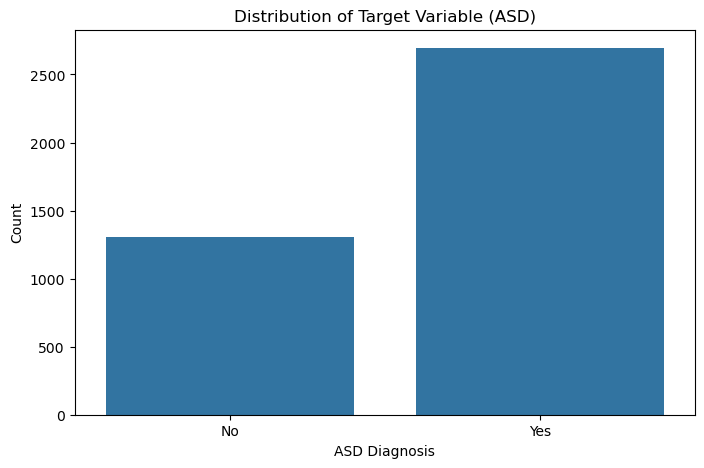

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Class_ASD_Traits ', data=data)
plt.title('Distribution of Target Variable (ASD)')
plt.xlabel('ASD Diagnosis')
plt.ylabel('Count')
plt.show()

In [8]:
sns.set_style('whitegrid')
data1=data[data['Class_ASD_Traits ']=='Yes']
print("Toddlers", len(data1)/len(data)*100)

Toddlers 67.38369184592297


#From this output we found that 67.38% of the toddlers in the dataset were positive in the ASD Diagnosis.

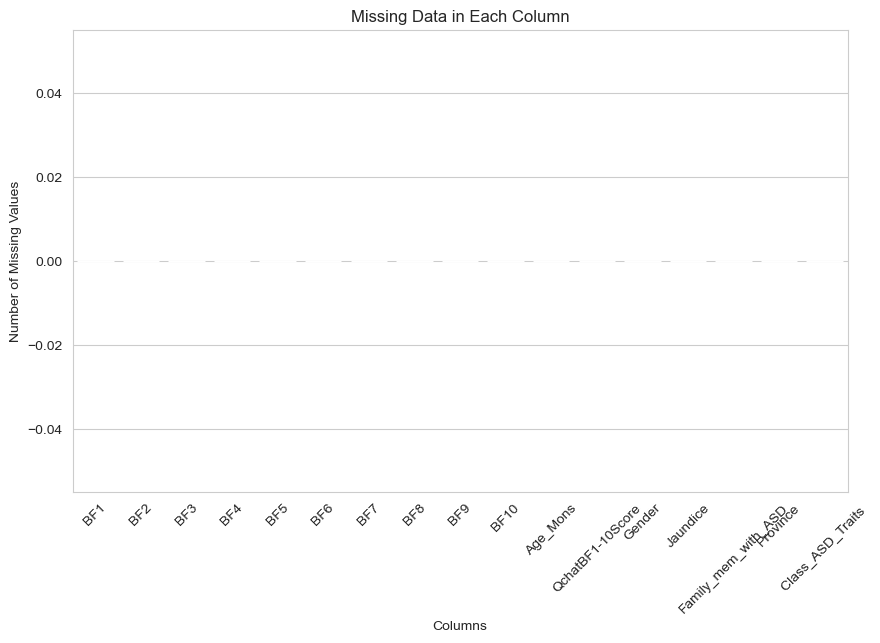

In [9]:
#Let's visualize the missing data
missing_data = data.isnull().sum()

# Create a bar plot for missing values
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_data.index, y=missing_data.values)
plt.title('Missing Data in Each Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.show()

#There were no null/missing values found

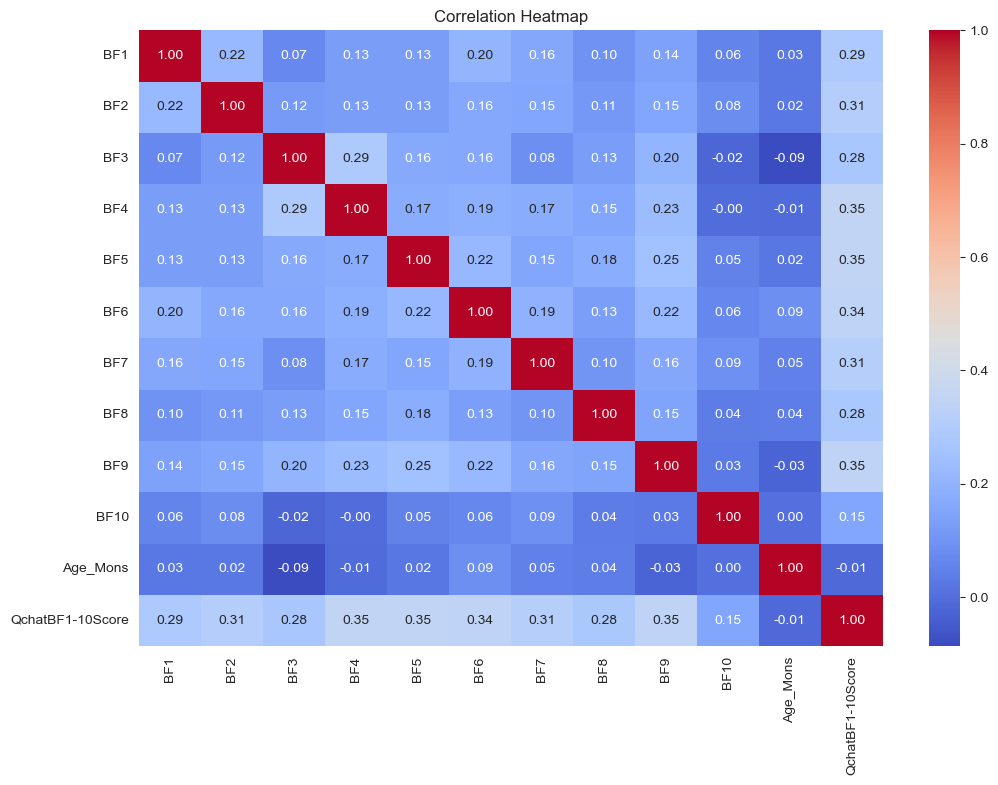

In [10]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
# Convert columns to numeric, errors='coerce' will replace non-numeric values with NaN
numeric_data = data.apply(pd.to_numeric, errors='coerce')
# Drop columns with all NaN values after conversion
numeric_data = numeric_data.dropna(axis=1, how='all')
correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#The highest correlation coefficient is 0.35, which is between BF4 and QchatBF1-10Score, BF5 and QchatBF1-10Score and BF9 and QchatBF1-10Score. The least correlation is between Age and QchatBF1-10Score.

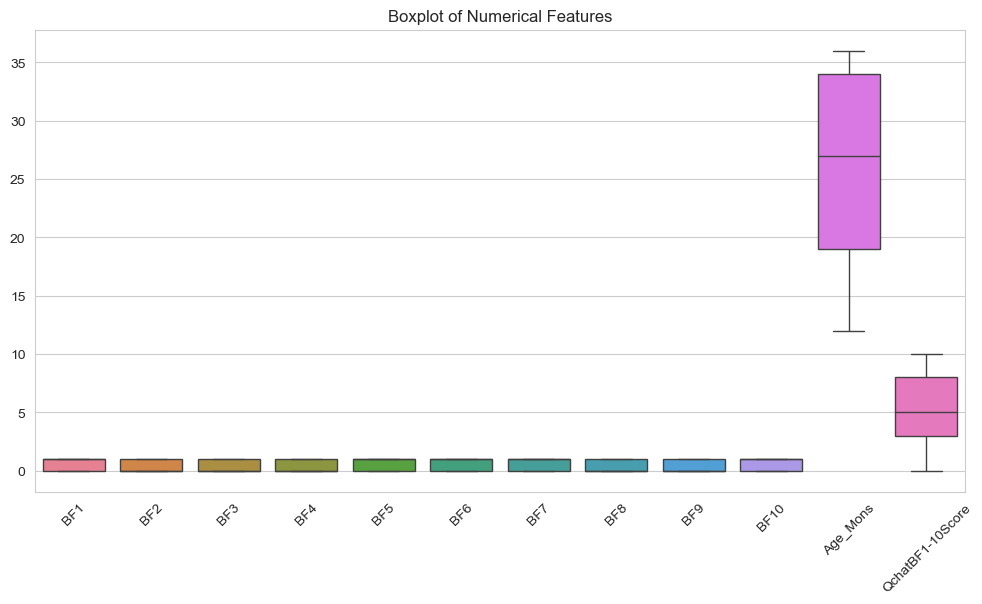

In [11]:
# Boxplot for numerical features
numerical_cols = ['BF1',	'BF2',	'BF3',	'BF4',	'BF5',	'BF6',	'BF7',	'BF8',	'BF9',	'BF10',	'Age_Mons',	'QchatBF1-10Score']
plt.figure(figsize=(12, 6))
sns.boxplot(data=data[numerical_cols])
plt.title('Boxplot of Numerical Features')
plt.xticks(rotation=45)
plt.show()

There were no outliers identified in BF1 to BF10

### EDA

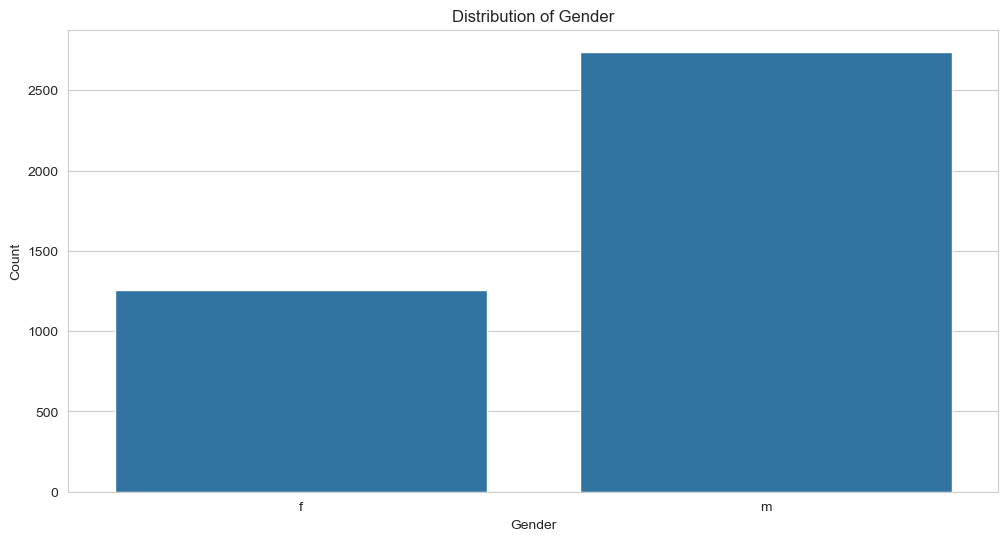

In [12]:
# Countplot for GENDER
plt.figure(figsize=(12, 6))
sns.countplot(x='Gender', data=data)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

The countplot shows that there are around 1350 males in contrast to around 620 females in the data.

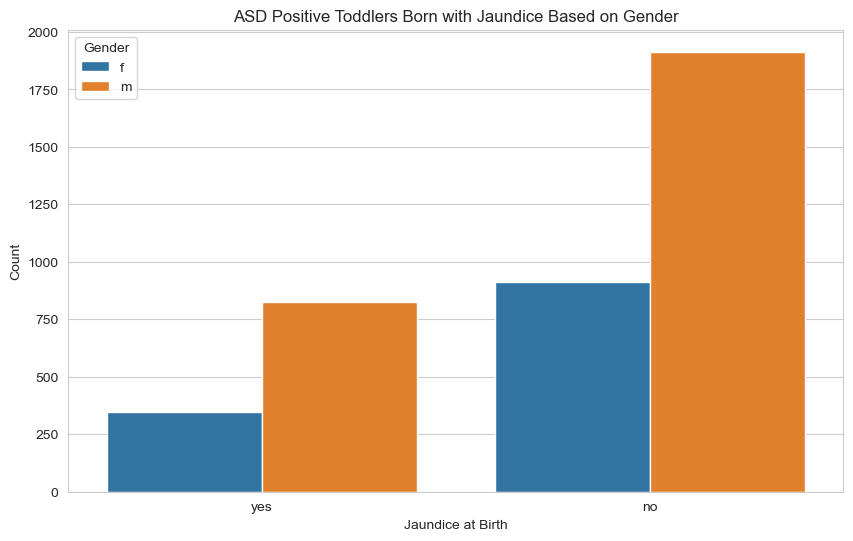

In [13]:
#visualizing the jaundice born toddlers based on gender
plt.figure(figsize=(10, 6))

# Create countplot for jaundice based on gender
sns.countplot(x='Jaundice', data=data, hue='Gender')

# Set the title and labels
plt.title('ASD Positive Toddlers Born with Jaundice Based on Gender')
plt.xlabel('Jaundice at Birth')
plt.ylabel('Count')

# Show the plot
plt.show()

Generally more ASD positive toddlers are born without jaundice.

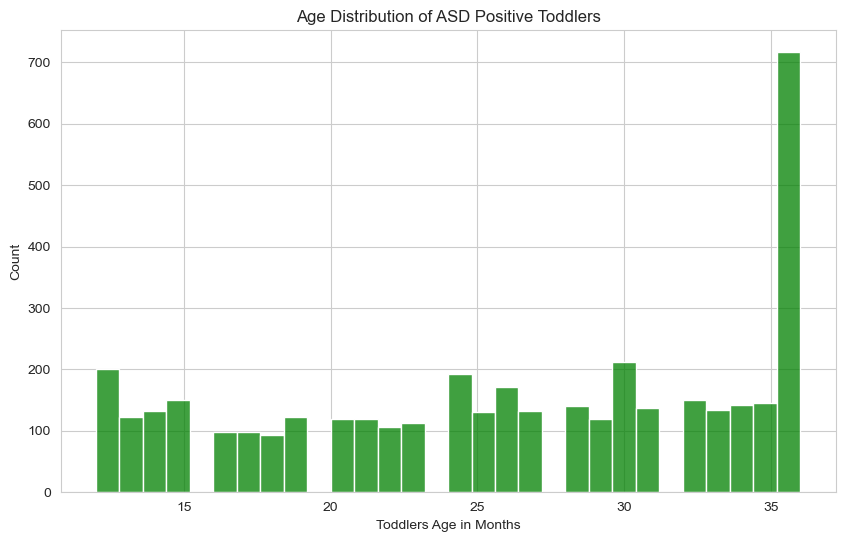

In [14]:
#Visualizing the age distribution of ASD positive
plt.figure(figsize=(10, 6))

# Create the distribution plot for Age_Mons
sns.histplot(data['Age_Mons'], bins=30, color='green', kde=False)

# Set the title and labels
plt.xlabel('Toddlers Age in Months')
plt.title('Age Distribution of ASD Positive Toddlers')

# Show the plot
plt.show()

From this output, it is vivid that ASD is most common in 36 months old toddlers.

In [15]:
#Visualizing the province value counts

data1['Province'].value_counts()

Province
Masvingo               896
Harare                 656
Manicaland             380
Midlands               242
Bulawayo               176
Mashonaland East       124
Matebelend South       110
Matebelend North        88
Mashonaland central     22
Name: count, dtype: int64

Most toddlers in this study are from Masvingo Province and Mashonaland central has the least.

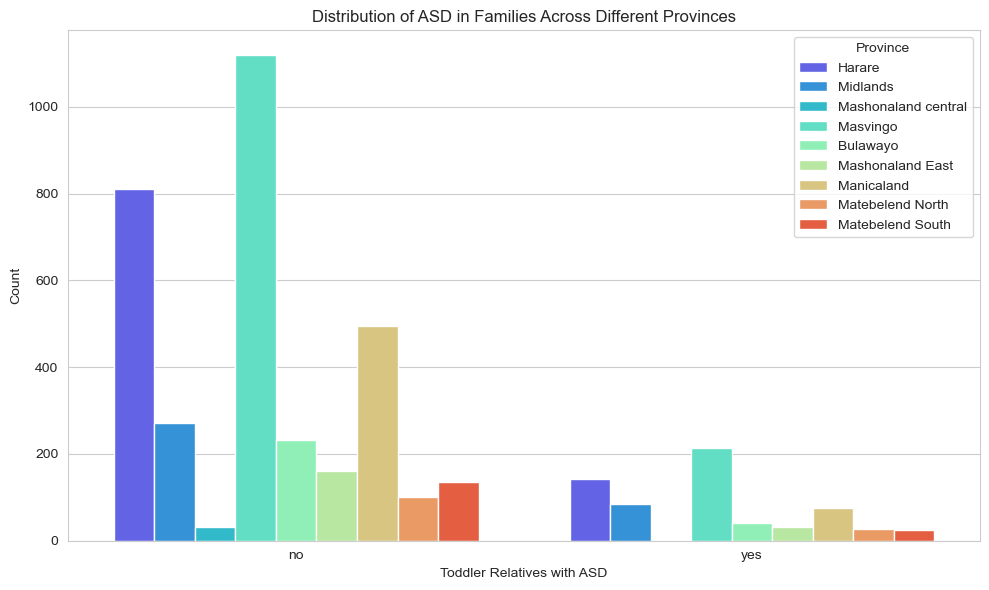

In [16]:
#visualizing the distribution of autism in family within different provinces
plt.figure(figsize=(10, 6))

# Create countplot for Family_mem_with_ASD with hue for Province
sns.countplot(x='Family_mem_with_ASD', data=data, hue='Province', palette='rainbow')

# Set the title and labels
plt.title('Distribution of ASD in Families Across Different Provinces')
plt.xlabel('Toddler Relatives with ASD')
plt.ylabel('Count')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

The majority of families in Mashonaland Central followed by Harare have no family member with ASD.

## Data Preprocessing

In [17]:
# Handle missing values (drop rows with missing target or fill others as appropriate)
data.dropna(subset=['Class_ASD_Traits '], inplace=True)

In [18]:
# One-hot encoding categorical features
data = pd.get_dummies(data, columns=['Gender', 'Province', 'Jaundice', 'Family_mem_with_ASD'], drop_first=True)

In [19]:
# Normalize numerical features
scaler = StandardScaler()
numerical_cols = ['Age_Mons', 'QchatBF1-10Score']
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

# Model Building

In [20]:
# Split features and target
X = data.drop(columns=['Class_ASD_Traits '])
y = pd.get_dummies(data['Class_ASD_Traits '], drop_first=True).iloc[:, 0]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

# Ensure X_train and X_test are C-contiguous
X_train = np.ascontiguousarray(X_train)
X_test = np.ascontiguousarray(X_test)

## Models

### i. Random Forest

In [21]:
rfc = RandomForestClassifier(n_estimators=1500, random_state=42)
rfc.fit(X_train, y_train)
y_pred_rfc = rfc.predict(X_test)

### ii. KNN

In [22]:
knn = KNeighborsClassifier(n_neighbors=13)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

## Hyperparameter Tunning

### i. Random Forest

In [23]:
param_grid_rf = {
    'n_estimators': [100, 500, 1000],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid_rf, cv=3, n_jobs=-1, scoring='accuracy')
rf_grid_search.fit(X_train, y_train)
best_rfc = rf_grid_search.best_estimator_
y_pred_best_rfc = best_rfc.predict(X_test)

### ii. KNN

In [24]:
param_grid_knn = {
    'n_neighbors': range(1, 30),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=param_grid_knn, cv=3, n_jobs=-1, scoring='accuracy')
knn_grid_search.fit(X_train, y_train)
best_knn = knn_grid_search.best_estimator_
y_pred_best_knn = best_knn.predict(X_test)

## Model Evaluation

In [25]:
models = {
    "Original Random Forest": (rfc, y_pred_rfc),
    "Tuned Random Forest": (best_rfc, y_pred_best_rfc),
    "Original KNN": (knn, y_pred_knn),
    "Tuned KNN": (best_knn, y_pred_best_knn)
}


Original Random Forest:
Accuracy: 0.96375
Classification Report:
               precision    recall  f1-score   support

       False       0.98      0.92      0.94       271
        True       0.96      0.99      0.97       529

    accuracy                           0.96       800
   macro avg       0.97      0.95      0.96       800
weighted avg       0.96      0.96      0.96       800



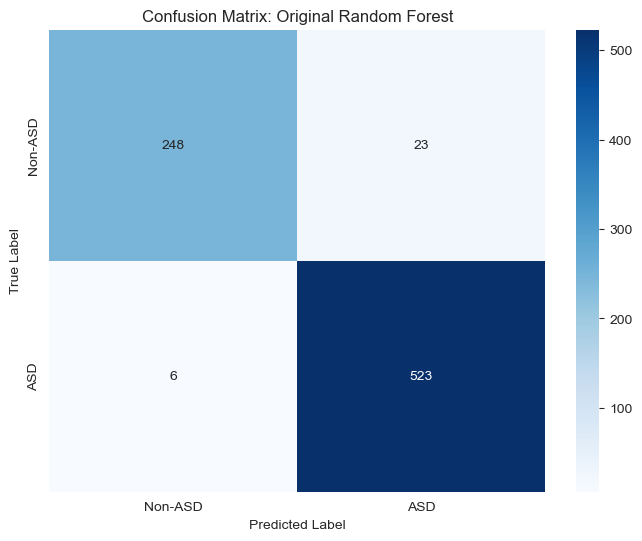

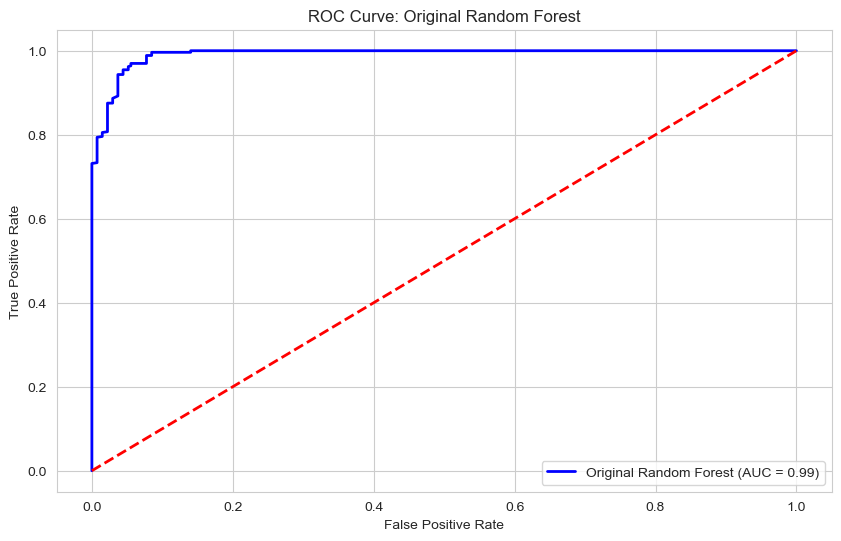


Tuned Random Forest:
Accuracy: 0.96625
Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.93      0.95       271
        True       0.96      0.98      0.97       529

    accuracy                           0.97       800
   macro avg       0.97      0.96      0.96       800
weighted avg       0.97      0.97      0.97       800



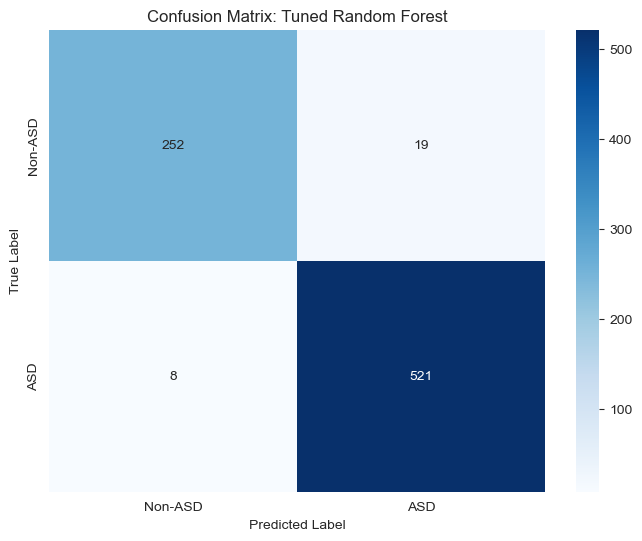

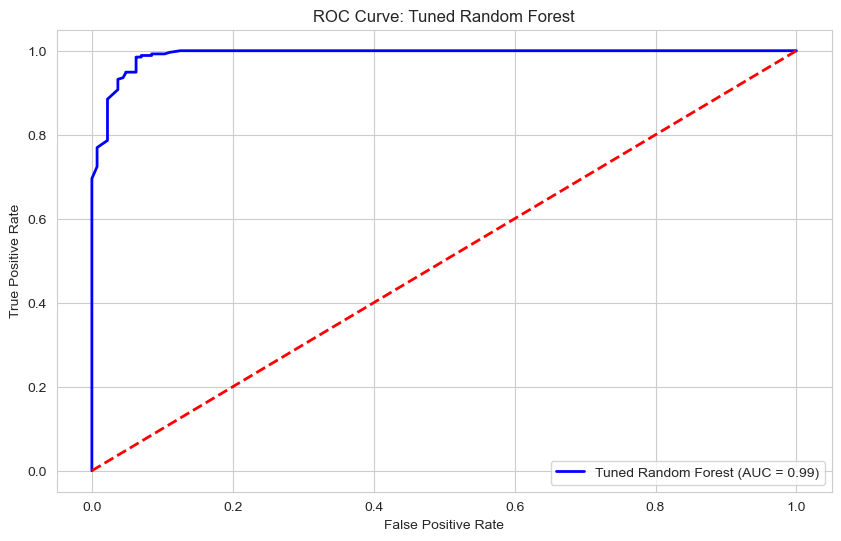


Original KNN:
Accuracy: 0.7875
Classification Report:
               precision    recall  f1-score   support

       False       0.71      0.62      0.66       271
        True       0.82      0.87      0.84       529

    accuracy                           0.79       800
   macro avg       0.77      0.75      0.75       800
weighted avg       0.78      0.79      0.78       800



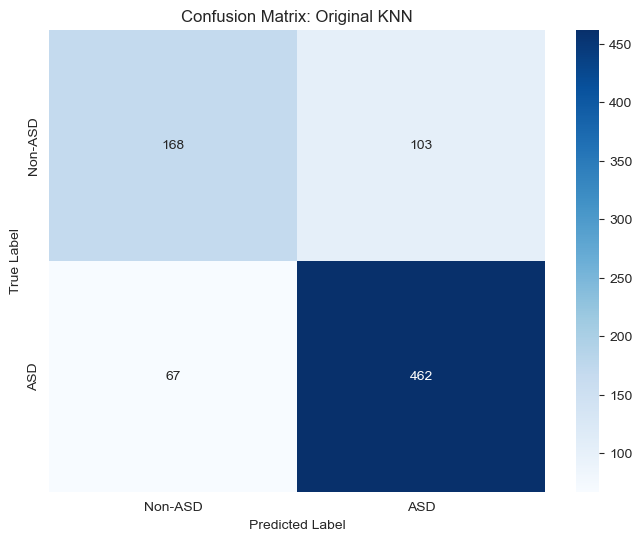

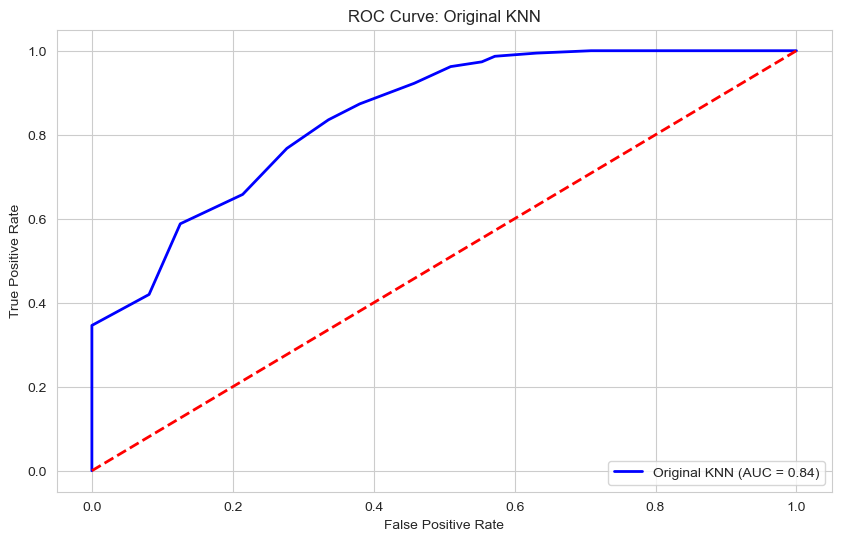


Tuned KNN:
Accuracy: 0.9525
Classification Report:
               precision    recall  f1-score   support

       False       0.94      0.92      0.93       271
        True       0.96      0.97      0.96       529

    accuracy                           0.95       800
   macro avg       0.95      0.94      0.95       800
weighted avg       0.95      0.95      0.95       800



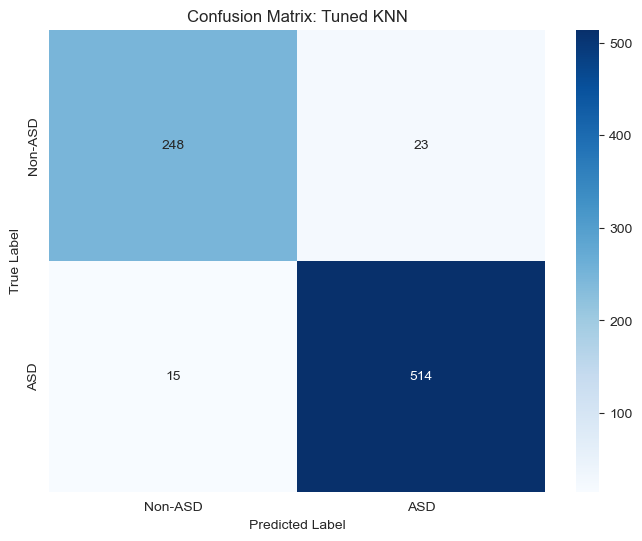

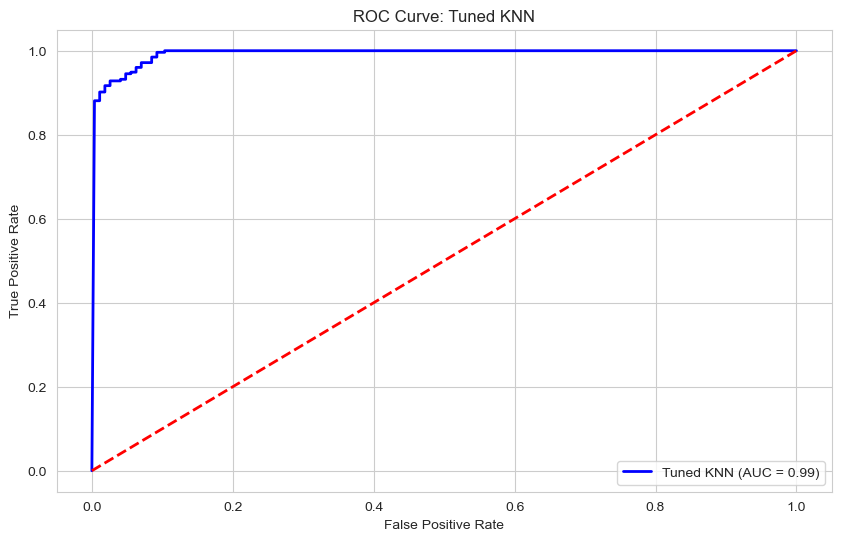


Model Performance Comparison:
                    Model  Accuracy
0  Original Random Forest   0.96375
1     Tuned Random Forest   0.96625
2            Original KNN   0.78750
3               Tuned KNN   0.95250


In [26]:
for name, (model, y_pred) in models.items():
    print(f"\n{name}:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-ASD', 'ASD'], yticklabels=['Non-ASD', 'ASD'])
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # ROC Curve
    if hasattr(model, "predict_proba"):
        fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 6))
        plt.plot(fpr, tpr, color='blue', lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve: {name}')
        plt.legend(loc='lower right')
        plt.show()

# Compare performance
comparison = {
    "Model": ["Original Random Forest", "Tuned Random Forest", "Original KNN", "Tuned KNN"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rfc),
        accuracy_score(y_test, y_pred_best_rfc),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_best_knn)
    ]
}
comparison_df = pd.DataFrame(comparison)
print("\nModel Performance Comparison:")
print(comparison_df)

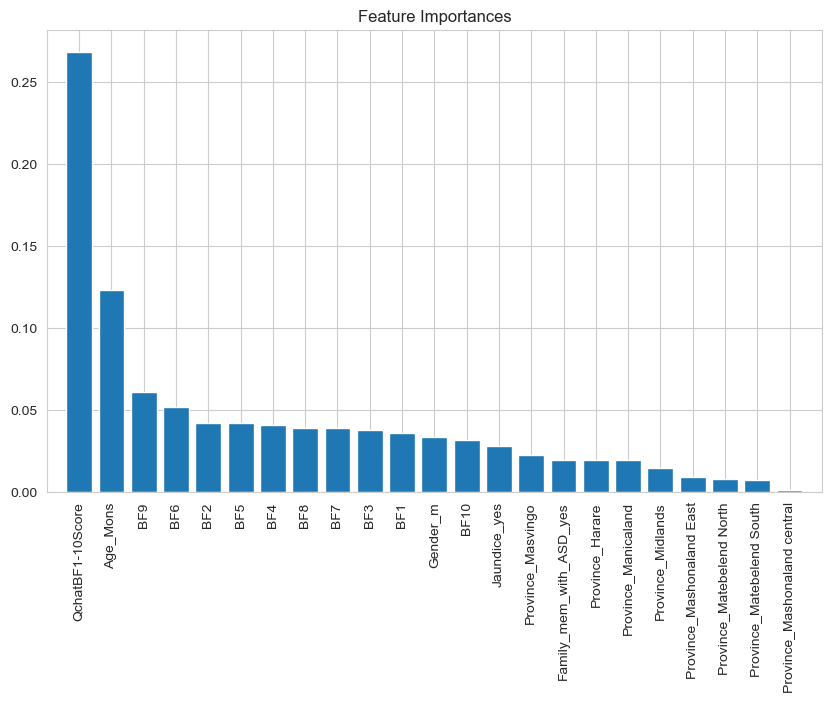

In [27]:
# Feature Importances for Random Forest
if hasattr(best_rfc, "feature_importances_"):
    feature_importances = best_rfc.feature_importances_
    indices = np.argsort(feature_importances)[::-1]

    plt.figure(figsize=(10, 6))
    plt.title('Feature Importances')
    plt.bar(range(X_train.shape[1]), feature_importances[indices], align='center')
    plt.xticks(range(X_train.shape[1]), X.columns[indices], rotation=90)
    plt.xlim([-1, X_train.shape[1]])
    plt.show()